# EDA - Memorias RAM PcComponentes - Datos Limpios

## Instrucciones para ejecutar

1. Ejecuta las celdas en orden, de arriba hacia abajo.
2. Introduce la contraseña de PostgreSQL cuando se solicite.
3. Los datos se consultarán desde la base de datos `pccomponentes_ml`.
4. Se mostrarán resultados, estadísticas y gráficos durante la ejecución.

## Objetivo

Explorar los datos limpios de memorias RAM almacenados en PostgreSQL.

Este análisis nos ayudará a:

- Comprobar el resultado de la limpieza.
- Analizar la distribución del catálogo.
- Revisar precios, especificaciones y opiniones.
- Comparar los resultados con el EDA de datos brutos.
- Identificar variables útiles para el clustering futuro.

**Datos utilizados:** tablas `productos`, `especificaciones_ram`, `distribucion_valoraciones` y `resenas` de PostgreSQL.

## 1. Carga de datos y preparación

In [1]:
# ============================================================
# CELDA 1: CARGA DE DATOS Y PREPARACIÓN DEL ENTORNO
# ============================================================
# - Importa las librerías necesarias para el análisis
# - Solicita la contraseña de PostgreSQL de forma segura
# - Conecta con la base de datos pccomponentes_ml
# - Configura la conexión como solo lectura
# - Prepara el estilo general de los gráficos
# ============================================================

from getpass import getpass

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
import seaborn as sns


# Estilo global para los gráficos del notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline


# Conexión segura con PostgreSQL
conn = psycopg.connect(
    dbname="pccomponentes_ml",
    user="postgres",
    password=getpass("Contraseña PostgreSQL: "),
    host="localhost",
    port=5432,
)

# Evita modificaciones accidentales en la base de datos
conn.execute("SET TRANSACTION READ ONLY")

print("Conexión de solo lectura creada correctamente")

Conexión de solo lectura creada correctamente


In [18]:
# ============================================================
# CELDA 2: CARGA DE LAS TABLAS LIMPIAS
# ============================================================
# - Ejecuta únicamente consultas SELECT
# - Convierte los resultados de PostgreSQL en DataFrames
# - Consulta solamente los datos de memoria RAM
# ============================================================

def consultar_dataframe(consulta):
    with conn.cursor() as cursor:
        cursor.execute(consulta)

        columnas = [
            columna.name
            for columna in cursor.description
        ]

        registros = cursor.fetchall()

    return pd.DataFrame(registros, columns=columnas)


productos = consultar_dataframe("""
    SELECT *
    FROM productos
    WHERE categoria = 'memoria_ram'
    ORDER BY producto_id;
""")


especificaciones = consultar_dataframe("""
    SELECT *
    FROM especificaciones_ram
    ORDER BY producto_id;
""")


distribuciones = consultar_dataframe("""
    SELECT d.*
    FROM distribucion_valoraciones AS d
    INNER JOIN productos AS p
        ON p.producto_id = d.producto_id
    WHERE p.categoria = 'memoria_ram'
    ORDER BY d.producto_id;
""")


resenas = consultar_dataframe("""
    SELECT r.*
    FROM resenas AS r
    INNER JOIN productos AS p
        ON p.producto_id = r.producto_id
    WHERE p.categoria = 'memoria_ram'
    ORDER BY r.producto_id, r.resena_id;
""")


print("Productos:", len(productos))
print("Especificaciones:", len(especificaciones))
print("Distribuciones:", len(distribuciones))
print("Reseñas:", len(resenas))

Productos: 1646
Especificaciones: 1574
Distribuciones: 1574
Reseñas: 5876


## 2. Resumen General del Dataset

Los datos limpios almacenados en PostgreSQL contienen:

- **Productos RAM:** 1646
- **Productos con especificaciones:** 1574
- **Distribuciones de valoraciones:** 1574
- **Reseñas:** 5876

La diferencia de 72 productos entre el catálogo y las especificaciones corresponde a productos que no estaban disponibles en el scraping de detalle.

In [3]:
# ============================================================
# CELDA 3: VISTA GENERAL DE LOS DATOS LIMPIOS
# ============================================================
# - Muestra una muestra de cada tabla
# - Comprueba sus dimensiones
# - Permite revisar las columnas y tipos de datos
# ============================================================

print("Dimensiones de las tablas:")
print("Productos:", productos.shape)
print("Especificaciones:", especificaciones.shape)
print("Distribuciones:", distribuciones.shape)
print("Reseñas:", resenas.shape)

display(productos.head())
display(especificaciones.head())
display(distribuciones.head())
display(resenas.head())


Dimensiones de las tablas:
Productos: (1646, 17)
Especificaciones: (1574, 14)
Distribuciones: (1574, 7)
Reseñas: (5876, 10)


,producto_id,nombre,url,sku,marca,categoria,precio,moneda,valoracion_media,total_opiniones,total_resenas_con_texto,porcentaje_recomendacion,numero_recomendaciones,pagina_origen,posicion_listado,presente_en_detalle,fuente
0,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,https://www.pccomponentes.com/memoria-ram-forg...,10996454,Forgeon,memoria_ram,449.95,EUR,4.68,106,76.0,52.83,56.0,1,1,True,pccomponentes_ram
1,ram_0002,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 16GB 2x8...,https://www.pccomponentes.com/memoria-ram-forg...,10931673,Forgeon,memoria_ram,139.95,EUR,4.74,336,239.0,69.35,233.0,1,2,True,pccomponentes_ram
2,ram_0003,Acer Predator Pallas II DDR5 6000MHz 32GB 2x16...,https://www.pccomponentes.com/memoria-ram-acer...,10871013,Acer,memoria_ram,409.95,EUR,4.67,227,168.0,66.08,150.0,1,3,True,pccomponentes_ram
3,ram_0004,Memoria RAM Acer Predator PALLASII 32GB 2x16GB...,https://www.pccomponentes.com/memoria-ram-acer...,10988963,Acer,memoria_ram,379.95,EUR,4.67,227,168.0,66.08,150.0,1,4,True,pccomponentes_ram
4,ram_0005,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 32GB 2x1...,https://www.pccomponentes.com/memoria-ram-forg...,10931674,Forgeon,memoria_ram,249.95,EUR,4.74,336,239.0,69.35,233.0,1,5,True,pccomponentes_ram


,producto_id,tipo_memoria,capacidad_gb,kit,num_modulos,capacidad_por_modulo_gb,frecuencia_mhz,latencia_cl,voltaje,diseno,compatibilidad,color,disipador,fuente
0,ram_0001,DDR5,32.00,2x16GB,2.0,16.00,6000.0,30.0,None,NaN,XMP/EXPO,Negra,None,nombre+html
1,ram_0002,DDR4,16.00,2x8GB,2.0,8.00,3200.0,16.0,None,NaN,XMP/EXPO,Negra,None,nombre+html
2,ram_0003,DDR5,32.00,2x16GB,2.0,16.00,6000.0,34.0,None,NaN,"AMD, EXPO, Intel, XMP",Negra,None,nombre+ld
3,ram_0004,DDR5,32.00,2x16GB,2.0,16.00,6000.0,34.0,None,NaN,"EXPO, XMP",Plata,None,nombre+ld
4,ram_0005,DDR4,32.00,2x16GB,2.0,16.00,3200.0,16.0,None,NaN,XMP/EXPO,Negra,None,nombre+html


,producto_id,estrellas_5,estrellas_4,estrellas_3,estrellas_2,estrellas_1,fuente_desglose
0,ram_0001,94,6,2,1,3,html_embebido
1,ram_0002,295,35,3,1,2,html_embebido
2,ram_0003,196,20,5,1,5,html_embebido
3,ram_0004,196,20,5,1,5,html_embebido
4,ram_0005,295,35,3,1,2,html_embebido


,resena_id,producto_id,valoracion,fecha_resena_texto,variante_modelo,texto_resena,pros,contras,likes,numero_respuestas
0,ram_0001_1,ram_0001,5.0,2025-03-05T17:27:28+00:00,None,"De momento muy bien,no he tenido problemas y f...",Ajustar el precio un poco más,NaN,None,None
1,ram_0001_10,ram_0001,5.0,2026-04-30T09:27:03+00:00,None,"Muy presencial, queda muy bonita la ram si tie...","Buenas presencia, rápida",El precio por decir algo,None,None
2,ram_0001_11,ram_0001,4.0,2026-05-18T23:38:50+00:00,None,"es bueno, rápido, ten cuidado con que durante ...",ta bueno,NaN,None,None
3,ram_0001_12,ram_0001,5.0,2026-05-28T11:36:35+00:00,None,"Es un buen producto, pero los precios suelen s...",velocidad,precio de mercado en 2026,None,None
4,ram_0001_13,ram_0001,0.5,2026-06-01T16:06:55+00:00,None,Ya me han enviado 2 veces consecutivas el prod...,NaN,No es el producto que compré,None,None


In [4]:
# ============================================================
# CELDA 4: TIPOS DE DATOS Y ESTADÍSTICAS GENERALES
# ============================================================
# - Convierte las columnas numéricas de PostgreSQL
# - Revisa tipos de datos
# - Muestra estadísticas descriptivas principales
# ============================================================

columnas_numericas_productos = [
    "precio",
    "valoracion_media",
    "porcentaje_recomendacion",
]

for columna in columnas_numericas_productos:
    productos[columna] = pd.to_numeric(
        productos[columna],
        errors="coerce",
    )

columnas_numericas_especificaciones = [
    "capacidad_gb",
    "capacidad_por_modulo_gb",
    "frecuencia_mhz",
    "latencia_cl",
    "voltaje",
]

for columna in columnas_numericas_especificaciones:
    especificaciones[columna] = pd.to_numeric(
        especificaciones[columna],
        errors="coerce",
    )

print("Información de productos:")
productos.info()

display(
    productos[
        [
            "precio",
            "valoracion_media",
            "total_opiniones",
            "porcentaje_recomendacion",
        ]
    ].describe()
)

Información de productos:
<class 'pandas.DataFrame'>
RangeIndex: 1646 entries, 0 to 1645
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   producto_id               1646 non-null   str    
 1   nombre                    1646 non-null   str    
 2   url                       1646 non-null   str    
 3   sku                       1646 non-null   str    
 4   marca                     1546 non-null   str    
 5   categoria                 1646 non-null   str    
 6   precio                    1646 non-null   float64
 7   moneda                    1646 non-null   str    
 8   valoracion_media          751 non-null    float64
 9   total_opiniones           1646 non-null   int64  
 10  total_resenas_con_texto   1574 non-null   float64
 11  porcentaje_recomendacion  716 non-null    float64
 12  numero_recomendaciones    1574 non-null   float64
 13  pagina_origen             1646 non-null   int64 

,precio,valoracion_media,total_opiniones,porcentaje_recomendacion
count,1646.000000,751.000000,1646.000000,716.000000
mean,555.636889,4.584767,57.019441,63.371327
std,628.781740,0.612964,316.789642,25.046884
min,1.210000,0.500000,0.000000,0.000000
25%,172.170000,4.545000,0.000000,51.535000
50%,374.230000,4.720000,0.000000,65.700000
75%,697.047500,4.860000,8.000000,76.520000
max,7681.060000,5.000000,6054.000000,100.000000


## 3. Análisis de Precios

Se analizará la distribución de precios de los productos RAM limpios.

Para visualizar mejor la mayoría del catálogo, se utilizará el percentil 99 como límite visual. Los productos superiores a ese valor no se eliminan de los datos.

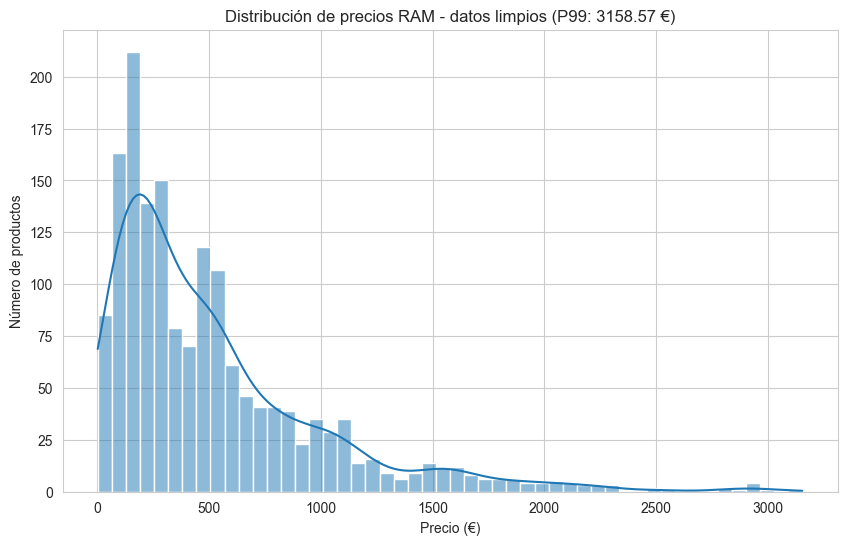

Percentil 99: 3158.57 €


In [5]:
# ============================================================
# CELDA 5: DISTRIBUCIÓN DE PRECIOS LIMPIOS
# ============================================================
# - Calcula el percentil 99 del precio
# - Evita que los valores extremos deformen la gráfica
# - El filtrado es únicamente visual
# ============================================================

precio_p99 = productos["precio"].quantile(0.99)

precios_filtrados = productos[
    productos["precio"] <= precio_p99
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=precios_filtrados,
    x="precio",
    bins=50,
    kde=True,
)

plt.title(
    "Distribución de precios RAM - datos limpios "
    f"(P99: {precio_p99:.2f} €)"
)
plt.xlabel("Precio (€)")
plt.ylabel("Número de productos")

plt.show()

print(f"Percentil 99: {precio_p99:.2f} €")

**Observaciones sobre los precios:**

- La distribución está sesgada hacia la derecha.
- La mayoría de productos se concentra en los rangos de precio más bajos y medios.
- Existen productos profesionales con precios superiores a 1000 €.
- El percentil 99 es 3158,57 €, por lo que solo el 1 % del catálogo supera aproximadamente ese precio.
- La mediana representa mejor el precio habitual que la media, debido a los valores elevados.
- La limpieza mantuvo los precios extremos porque pueden corresponder a productos reales de gran capacidad.

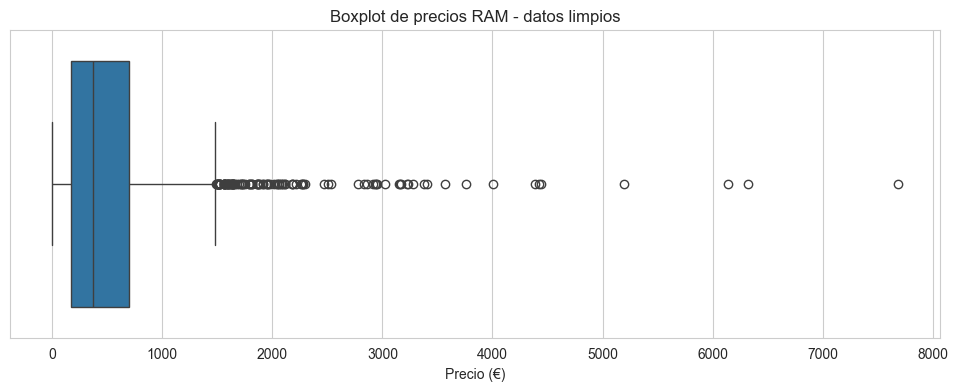

Límite superior: 1484.36 €
Productos considerados outliers: 115


In [6]:
# ============================================================
# CELDA 6: BOXPLOT Y OUTLIERS DE PRECIO
# ============================================================
# - Visualiza la dispersión completa de precios
# - Calcula los límites mediante el rango intercuartílico
# - Identifica cuántos productos son outliers estadísticos
# ============================================================

q1 = productos["precio"].quantile(0.25)
q3 = productos["precio"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_precio = productos[
    (productos["precio"] < limite_inferior)
    | (productos["precio"] > limite_superior)
]

plt.figure(figsize=(12, 4))
sns.boxplot(x=productos["precio"])

plt.title("Boxplot de precios RAM - datos limpios")
plt.xlabel("Precio (€)")

plt.show()

print(f"Límite superior: {limite_superior:.2f} €")
print(f"Productos considerados outliers: {len(outliers_precio)}")

**Observaciones del boxplot:**

- El límite superior calculado mediante IQR es 1484,36 €.
- Se identifican 115 productos como outliers estadísticos.
- Estos productos no se eliminan, porque pueden corresponder a memorias profesionales o kits de gran capacidad.
- El resultado es muy similar al EDA bruto, donde también se detectó una cola importante de precios elevados.

## 4. Especificaciones Técnicas

Se analizarán el tipo de memoria, la capacidad, la frecuencia y la latencia de los productos RAM después de la limpieza.

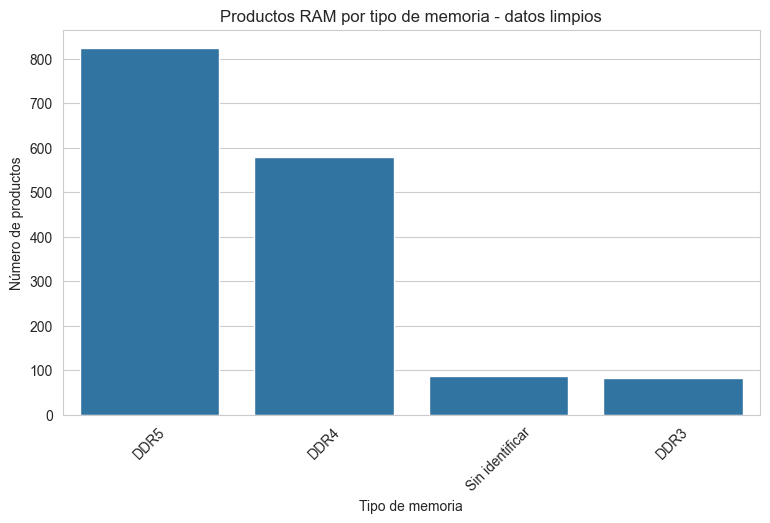

tipo_memoria
DDR5               824
DDR4               580
Sin identificar     87
DDR3                83
Name: count, dtype: int64

In [7]:
# ============================================================
# CELDA 7: DISTRIBUCIÓN POR TIPO DE MEMORIA
# ============================================================
# - Cuenta los productos por tecnología de memoria
# - Mantiene visibles los valores sin identificar
# ============================================================

tipos_memoria = (
    especificaciones["tipo_memoria"]
    .fillna("Sin identificar")
    .value_counts()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=tipos_memoria.index,
    y=tipos_memoria.values,
)

plt.title("Productos RAM por tipo de memoria - datos limpios")
plt.xlabel("Tipo de memoria")
plt.ylabel("Número de productos")
plt.xticks(rotation=45)

plt.show()

display(tipos_memoria)

**Observaciones sobre el tipo de memoria:**

- DDR5 es la tecnología más frecuente, con 824 productos.
- DDR4 sigue teniendo una presencia importante, con 580 productos.
- DDR3 representa una parte menor del catálogo, con 83 productos.
- Hay 87 productos sin tipo de memoria identificado.
- Los resultados confirman la transición del mercado hacia DDR5.

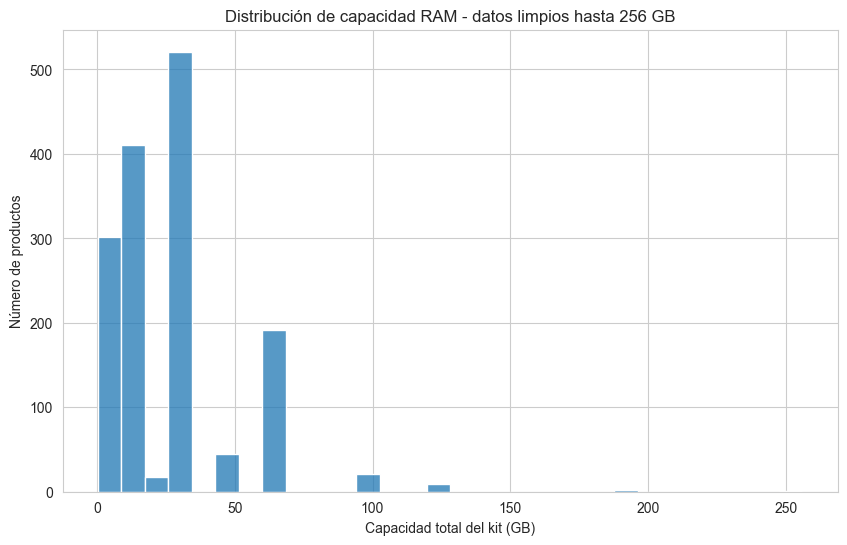

Productos con capacidad identificada: 1520
Productos con capacidad superior a 256 GB: 0
Capacidad máxima: 256.0 GB


In [8]:
# ============================================================
# CELDA 8: DISTRIBUCIÓN DE CAPACIDAD RAM
# ============================================================
# - Analiza las capacidades limpias
# - Limita la gráfica a 256 GB para mostrar los kits habituales
# - Informa de los productos superiores a ese valor
# ============================================================

capacidad = especificaciones["capacidad_gb"].dropna()

capacidad_habitual = capacidad[
    (capacidad > 0)
    & (capacidad <= 256)
]

capacidades_superiores = capacidad[
    capacidad > 256
]

plt.figure(figsize=(10, 6))

sns.histplot(
    capacidad_habitual,
    bins=30,
)

plt.title(
    "Distribución de capacidad RAM - "
    "datos limpios hasta 256 GB"
)
plt.xlabel("Capacidad total del kit (GB)")
plt.ylabel("Número de productos")

plt.show()

print(
    "Productos con capacidad identificada:",
    len(capacidad),
)
print(
    "Productos con capacidad superior a 256 GB:",
    len(capacidades_superiores),
)
print(
    "Capacidad máxima:",
    capacidad.max(),
    "GB",
)

### Observaciones sobre la capacidad

- Se ha identificado la capacidad en 1520 productos.
- No aparecen capacidades superiores a 256 GB.
- La capacidad máxima registrada es de 256 GB.
- Las capacidades se concentran principalmente en los tamaños habituales del mercado.
- La corrección aplicada evita confundir códigos de modelo con capacidades de memoria.

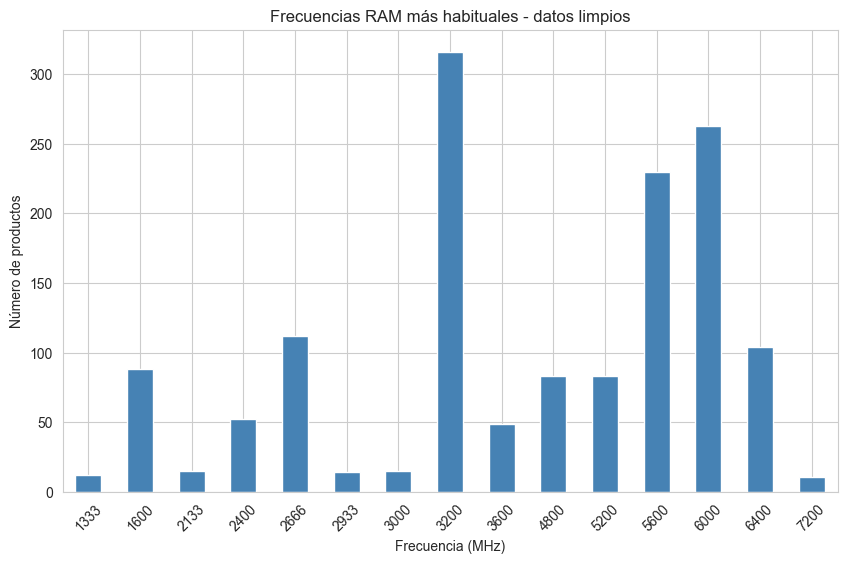

frecuencia_mhz
3200    316
6000    263
5600    230
2666    112
6400    104
1600     88
4800     83
5200     83
2400     52
3600     49
3000     15
2133     15
2933     14
1333     12
7200     11
Name: count, dtype: int64


In [10]:
# ============================================================
# CELDA 9: DISTRIBUCIÓN DE FRECUENCIAS RAM
# ============================================================
# - Analiza las frecuencias limpias
# - Muestra las 15 frecuencias más habituales
# ============================================================

frecuencias = (
    especificaciones["frecuencia_mhz"]
    .dropna()
    .astype(int)
    .value_counts()
    .head(15)
    .sort_index()
)

plt.figure(figsize=(10, 6))

frecuencias.plot(
    kind="bar",
    color="steelblue",
)

plt.title(
    "Frecuencias RAM más habituales - datos limpios"
)
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("Número de productos")
plt.xticks(rotation=45)

plt.show()

print(frecuencias.sort_values(ascending=False))

### Observaciones sobre la frecuencia

- La frecuencia más común es 3200 MHz, habitual en memorias DDR4.
- En DDR5 destacan especialmente las frecuencias de 5600 y 6000 MHz.
- También aparecen frecuencias inferiores, como 1333, 1600 y 2133 MHz, asociadas principalmente a generaciones anteriores.
- La distribución refleja la convivencia de distintas generaciones de memoria RAM en el catálogo.

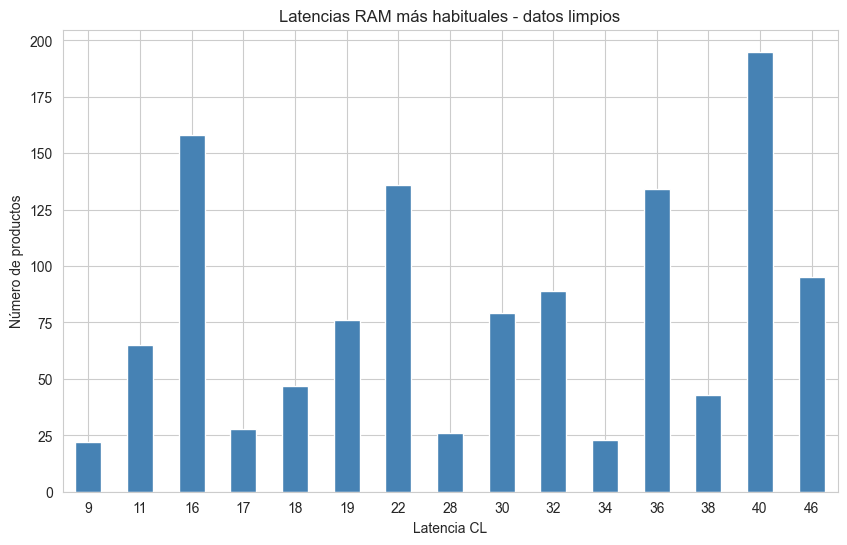

latencia_cl
40    195
16    158
22    136
36    134
46     95
32     89
30     79
19     76
11     65
18     47
38     43
17     28
28     26
34     23
9      22
Name: count, dtype: int64


In [11]:
# ============================================================
# CELDA 10: DISTRIBUCIÓN DE LATENCIAS RAM
# ============================================================
# - Analiza las latencias CL limpias
# - Muestra las 15 latencias más habituales
# ============================================================

latencias = (
    especificaciones["latencia_cl"]
    .dropna()
    .astype(int)
    .value_counts()
    .head(15)
    .sort_index()
)

plt.figure(figsize=(10, 6))

latencias.plot(
    kind="bar",
    color="steelblue",
)

plt.title(
    "Latencias RAM más habituales - datos limpios"
)
plt.xlabel("Latencia CL")
plt.ylabel("Número de productos")
plt.xticks(rotation=0)

plt.show()

print(latencias.sort_values(ascending=False))

### Observaciones sobre la latencia

- La latencia más frecuente es CL40, seguida de CL16, CL22 y CL36.
- Las latencias CL16 y CL18 son habituales en memorias DDR4.
- Las latencias CL36, CL40 y CL46 aparecen principalmente en memorias DDR5.
- Las diferencias observadas responden a las características propias de cada generación y frecuencia de memoria.

## 5. El problema del voltaje (campo crítico)

In [19]:
# ============================================================
# CELDA 11: COMPROBACIÓN DEL VOLTAJE
# ============================================================
# - Comprueba cuántos productos tienen voltaje
# ============================================================

voltajes = especificaciones["voltaje"].dropna()

print(
    "Productos con voltaje:",
    len(voltajes),
)
print(
    "Productos sin voltaje:",
    especificaciones["voltaje"].isna().sum(),
)

Productos con voltaje: 0
Productos sin voltaje: 1574


### Conclusión sobre el voltaje

El campo `voltaje` está vacío en todos los productos. Este problema ya apareció en el análisis de los datos brutos.

Para obtener este dato habría que mejorar el scraper. Por ahora, el voltaje no se utilizará en los siguientes análisis.

## 6. Reseñas y valoraciones de usuarios

In [13]:
# ============================================================
# CELDA 12: RESEÑAS Y VALORACIONES DE USUARIOS
# ============================================================
# - Resume las reseñas guardadas en PostgreSQL
# - Muestra las valoraciones y la cobertura de pros y contras
# ============================================================

print("Total de reseñas:", len(resenas))
print(
    "Reseñas por producto:",
    round(len(resenas) / len(especificaciones), 1),
)

print("\nDistribución de valoraciones:")
print(
    resenas["valoracion"]
    .value_counts()
    .sort_index()
)

print(
    "\nPorcentaje con pros:",
    round(resenas["pros"].notna().mean() * 100, 1),
)
print(
    "Porcentaje con contras:",
    round(resenas["contras"].notna().mean() * 100, 1),
)

Total de reseñas: 5876
Reseñas por producto: 3.7

Distribución de valoraciones:
valoracion
0.5      34
1.0      34
1.5       9
2.0      24
2.5      24
3.0     106
3.5     112
4.0     502
4.5     679
5.0    4352
Name: count, dtype: int64

Porcentaje con pros: 60.1
Porcentaje con contras: 52.6


### Observaciones sobre las reseñas

- Se han recogido 5876 reseñas, unas 3,7 por producto.
- La mayoría tiene una valoración de 5 estrellas.
- El 60,1 % incluye pros y el 52,6 % incluye contras.
- Las valoraciones están bastante concentradas en puntuaciones altas.

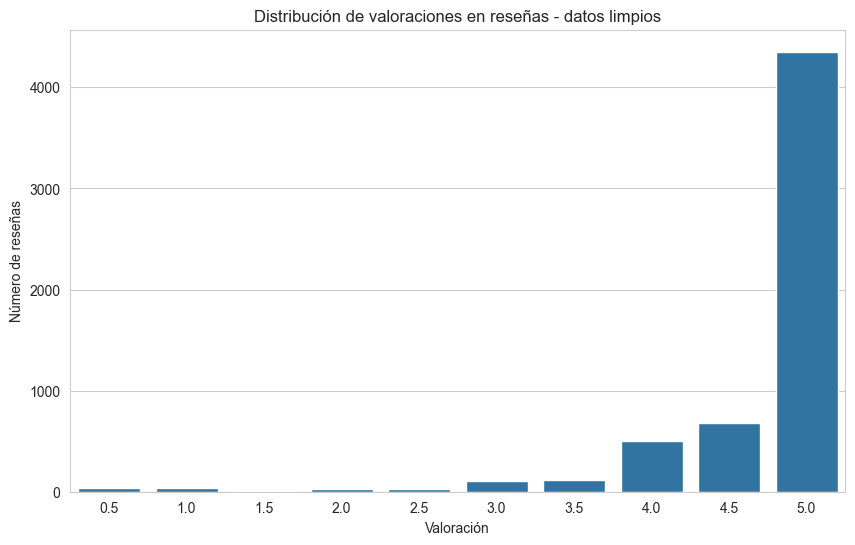

In [14]:
# ============================================================
# CELDA 13: DISTRIBUCIÓN DE VALORACIONES
# ============================================================
# - Muestra cuántas reseñas hay para cada valoración
# ============================================================

valoraciones = (
    resenas["valoracion"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=valoraciones.index.astype(str),
    y=valoraciones.values,
)

plt.title(
    "Distribución de valoraciones en reseñas - datos limpios"
)
plt.xlabel("Valoración")
plt.ylabel("Número de reseñas")

plt.show()

### Lectura de la gráfica

La mayoría de las reseñas tiene una valoración de 5 estrellas. Las valoraciones bajas son mucho menos frecuentes. Por tanto, las opiniones recogidas son principalmente positivas.

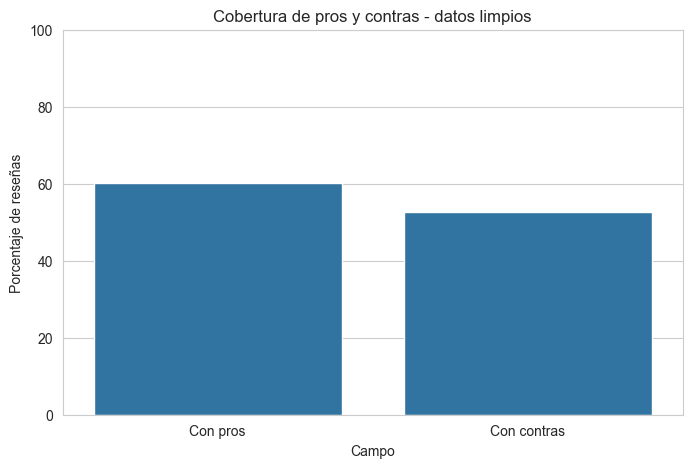

In [15]:
# ============================================================
# CELDA 14: COBERTURA DE PROS Y CONTRAS
# ============================================================

cobertura = pd.Series({
    "Con pros": resenas["pros"].notna().mean() * 100,
    "Con contras": resenas["contras"].notna().mean() * 100,
})

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cobertura.index,
    y=cobertura.values,
)

plt.title("Cobertura de pros y contras - datos limpios")
plt.xlabel("Campo")
plt.ylabel("Porcentaje de reseñas")
plt.ylim(0, 100)

plt.show()

### Lectura de la gráfica

Algo más de la mitad de las reseñas incluye pros y contras. Estos campos tienen suficiente contenido para analizarlos más adelante.

## 7. Análisis de marcas

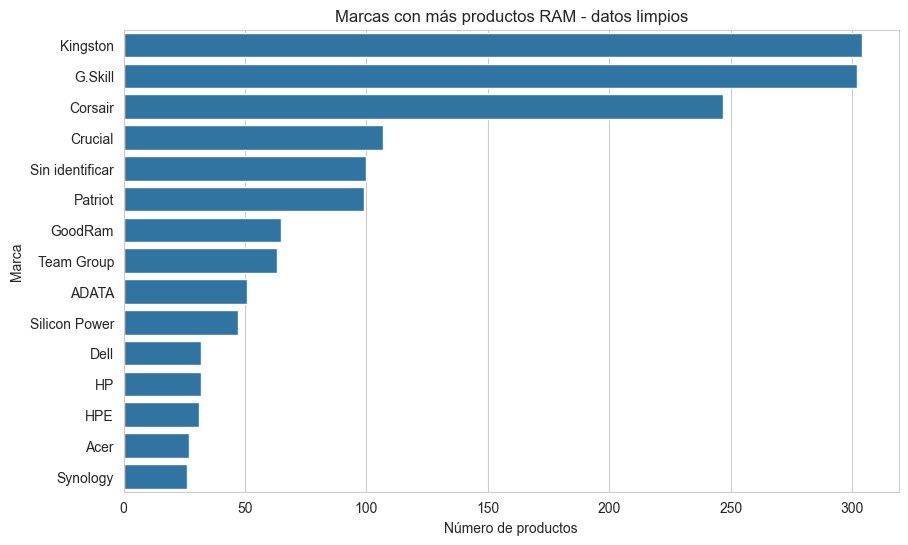

marca
Kingston           304
G.Skill            302
Corsair            247
Crucial            107
Sin identificar    100
Patriot             99
GoodRam             65
Team Group          63
ADATA               51
Silicon Power       47
Dell                32
HP                  32
HPE                 31
Acer                27
Synology            26
Name: count, dtype: int64


In [16]:
# ============================================================
# CELDA 15: MARCAS MÁS FRECUENTES
# ============================================================

marcas = (
    productos["marca"]
    .fillna("Sin identificar")
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=marcas.values,
    y=marcas.index,
)

plt.title("Marcas con más productos RAM - datos limpios")
plt.xlabel("Número de productos")
plt.ylabel("Marca")

plt.show()

print(marcas)

### Observaciones sobre las marcas

Kingston y G.Skill son las marcas con más productos. Después aparece Corsair. También hay algunos productos cuya marca no se ha podido identificar.

## 8. Calidad de los datos

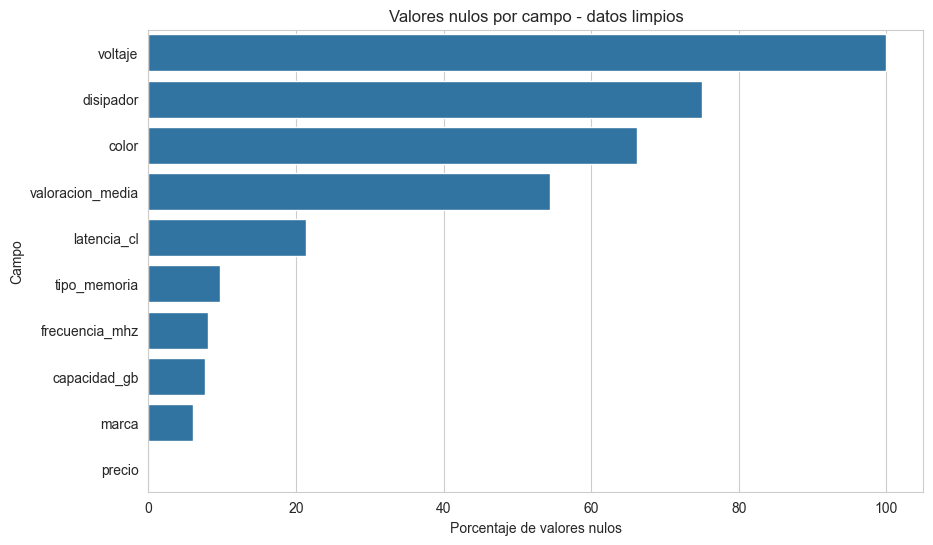

voltaje             100.0
disipador            75.0
color                66.2
valoracion_media     54.4
latencia_cl          21.3
tipo_memoria          9.7
frecuencia_mhz        8.1
capacidad_gb          7.7
marca                 6.1
precio                0.0
dtype: float64


In [17]:
# ============================================================
# CELDA 16: VALORES NULOS
# ============================================================

datos_ram = productos.merge(
    especificaciones,
    on="producto_id",
    how="left",
)

columnas = [
    "marca",
    "precio",
    "valoracion_media",
    "tipo_memoria",
    "capacidad_gb",
    "frecuencia_mhz",
    "latencia_cl",
    "voltaje",
    "color",
    "disipador",
]

porcentaje_nulos = (
    datos_ram[columnas]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=porcentaje_nulos.values,
    y=porcentaje_nulos.index,
)

plt.title("Valores nulos por campo - datos limpios")
plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Campo")

plt.show()

print(porcentaje_nulos.round(1))

### Observaciones sobre los valores nulos

- El voltaje está vacío en todos los productos, tal y como se ha comentado anteriormente.
- En muchos productos no aparece información sobre el disipador ni el color.
- En la mayoría de los productos sí aparecen la latencia, el tipo de memoria, la frecuencia y la capacidad.
- El precio está completo en todos los productos.

## 9. Cambios después de la limpieza

La limpieza ha corregido los caracteres mal codificados y las capacidades que se confundían con códigos de modelo.

Ya no aparecen capacidades superiores a 256 GB. Los campos que no estaban disponibles en los datos brutos, como el voltaje, siguen vacíos.

## 10. Conclusiones

- Se han analizado 1646 productos RAM y 5876 reseñas.
- DDR5 es el tipo de memoria más común, seguido de DDR4.
- Las frecuencias que más aparecen son 3200, 5600 y 6000 MHz.
- La mayoría de las reseñas tiene una valoración alta.
- Después de la limpieza ya no aparecen capacidades incorrectas ni textos mal codificados.
- El voltaje sigue sin tener datos.
- El precio, la capacidad, la frecuencia, la latencia y el tipo de memoria podrán utilizarse en los siguientes análisis.

In [20]:
# ============================================================
# CELDA 17: CIERRE DE LA CONEXIÓN
# ============================================================

conn.close()

print("Conexión cerrada")

Conexión cerrada
